# GLANCE30 Land Cover Visualization

This notebook demonstrates how to visualize GLANCE30 land cover data using xarray and matplotlib.

File: `GLANCE30_A20190701_h13v41_001_20220824_NA_LC.tif.nc4`

- Tile: h13v41 (MODIS sinusoidal grid)
- Date: 2019-07-01
- Region: North America (NA)
- Resolution: 30m

In [1]:
# Import required libraries
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

# Set figure style
plt.style.use('default')
%matplotlib inline

## 1. Load the Dataset

In [2]:
# Load the NetCDF file
ds = xr.open_dataset('GLANCE30_A20190701_h13v41_001_20220824_NA_LC.tif.nc4')
print(ds)

<xarray.Dataset>
Dimensions:  (dim0: 5000, dim1: 5000)
Coordinates:
    lon0     (dim0, dim1) float64 ...
    lat0     (dim0, dim1) float64 ...
Dimensions without coordinates: dim0, dim1
Data variables:
    image0   (dim0, dim1) float32 ...
Attributes: (12/16)
    GeoTransform:                  -5683670 30 0 -1073535 0 -30
    origin:                        (-5683670, -1073535)
    pixel_size:                    (30, -30)
    CornerCoordinates_UpperLeft:   (-5683670.0000000, -1073535.0000000)
    CornerCoordinates_LowerLeft:   (-5683670.0000000, -1223535.0000000)
    CornerCoordinates_UpperRight:  (-5533670.0000000, -1073535.0000000)
    ...                            ...
    AREA_OR_POINT:                 Area
    COMPRESSION:                   LZW
    INTERLEAVE:                    BAND
    NoData:                        255
    history:                       2026-03-13 15:05:30 GMT hyrax-Not.A.Releas...
    history_json:                  [{"$schema":"https:\/\/harmony.earthdata.n...

In [3]:
# Examine the data variable
land_cover = ds['image0']
print(f"Data shape: {land_cover.shape}")
print(f"Data type: {land_cover.dtype}")
print(f"NoData value: {ds.attrs.get('NoData', 'Not specified')}")

Data shape: (5000, 5000)
Data type: float32
NoData value: 255


In [4]:
# Examine unique values in the dataset
unique_values = np.unique(land_cover.values[~np.isnan(land_cover.values)])
print(f"Unique land cover classes: {unique_values}")
print(f"Number of classes: {len(unique_values)}")

Unique land cover classes: [1. 3. 4. 5. 6. 7.]
Number of classes: 6


## 2. Define Land Cover Color Map

Create a color map for common land cover classifications. You may need to adjust this based on the actual classification scheme used in GLANCE30.

In [5]:
# Define a color scheme for land cover types
# This is a generic scheme - adjust based on GLANCE30 classification
lc_colors = {
    0: '#000000',    # NoData/Unclassified - Black
    1: '#006400',    # Evergreen Needleleaf Forest - Dark Green
    2: '#00FF00',    # Evergreen Broadleaf Forest - Bright Green
    3: '#228B22',    # Deciduous Needleleaf Forest - Forest Green
    4: '#32CD32',    # Deciduous Broadleaf Forest - Lime Green
    5: '#90EE90',    # Mixed Forest - Light Green
    6: '#F0E68C',    # Closed Shrublands - Khaki
    7: '#FFD700',    # Open Shrublands - Gold
    8: '#FFFF00',    # Woody Savannas - Yellow
    9: '#ADFF2F',    # Savannas - Yellow Green
    10: '#7CFC00',   # Grasslands - Lawn Green
    11: '#87CEEB',   # Permanent Wetlands - Sky Blue
    12: '#FFB6C1',   # Croplands - Light Pink
    13: '#FF0000',   # Urban and Built-up - Red
    14: '#FF69B4',   # Cropland/Natural Vegetation Mosaic - Hot Pink
    15: '#FFFFFF',   # Snow and Ice - White
    16: '#F4A460',   # Barren or Sparsely Vegetated - Sandy Brown
    17: '#0000FF',   # Water - Blue
}

# Get actual values from data to create appropriate colormap
actual_values = sorted([int(v) for v in unique_values if not np.isnan(v)])
colors = [lc_colors.get(v, '#808080') for v in actual_values]

# Create colormap
cmap = ListedColormap(colors)
norm = BoundaryNorm(actual_values + [max(actual_values) + 1], cmap.N)

## 3. Global Map Visualization

Visualize the land cover data in its geographic context on a global map.

/Users/hyoklee/miniconda3/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


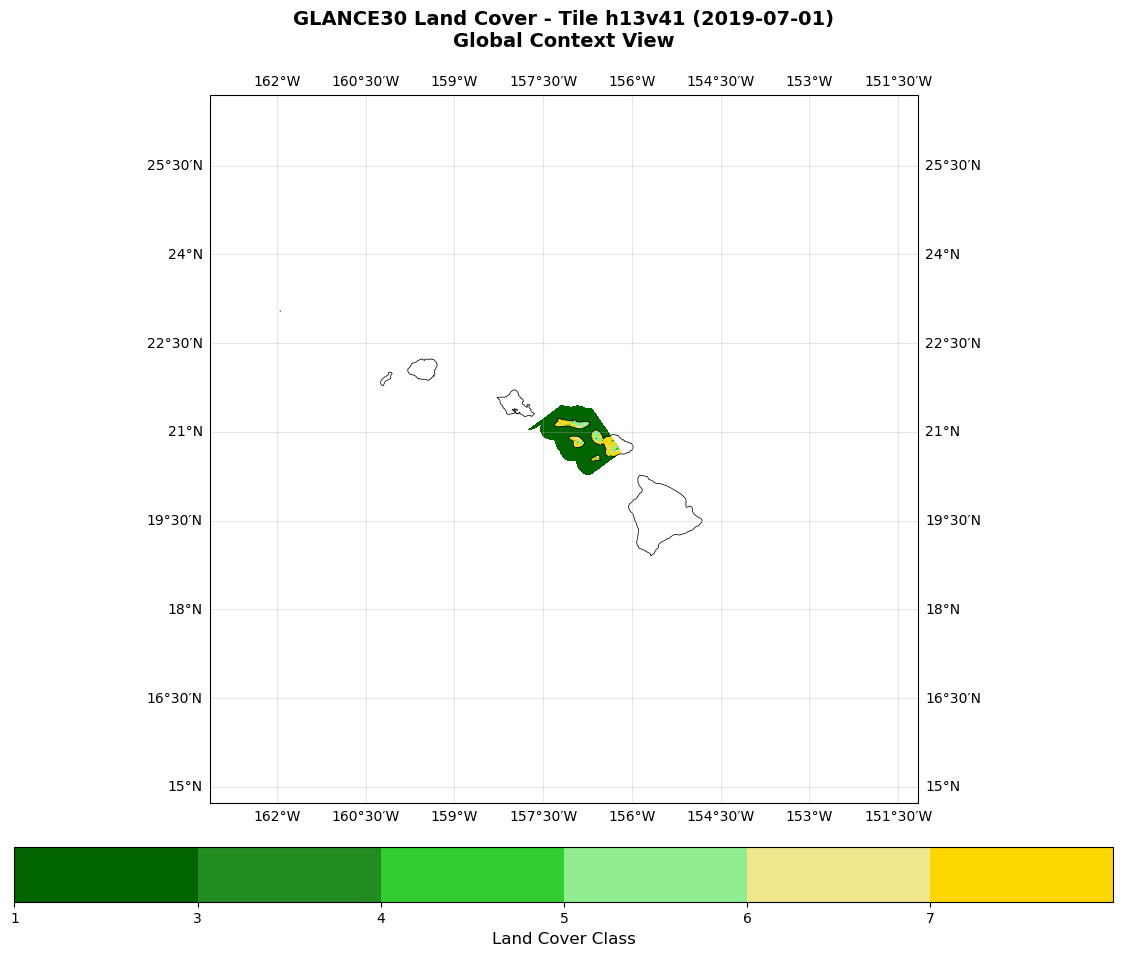

Data extent: Lon [-158.13, -156.16], Lat [19.73, 21.69]


In [6]:
# Create figure with global projection
fig = plt.figure(figsize=(16, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.2, alpha=0.3)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)

# Plot the land cover data
# Using pcolormesh with the lat/lon coordinates
im = ax.pcolormesh(
    ds['lon0'], 
    ds['lat0'], 
    land_cover,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    shading='auto'
)

# Set extent to focus on data region
lon_min, lon_max = float(ds['lon0'].min()), float(ds['lon0'].max())
lat_min, lat_max = float(ds['lat0'].min()), float(ds['lat0'].max())
ax.set_extent([lon_min - 5, lon_max + 5, lat_min - 5, lat_max + 5], crs=ccrs.PlateCarree())

# Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cbar.set_label('Land Cover Class', fontsize=12)
cbar.set_ticks(actual_values)

# Title
plt.title('GLANCE30 Land Cover - Tile h13v41 (2019-07-01)\nGlobal Context View', 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('glance30_global_view.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Data extent: Lon [{lon_min:.2f}, {lon_max:.2f}], Lat [{lat_min:.2f}, {lat_max:.2f}]")

## 4. Zoomed Map Visualization

Create a zoomed-in view focused on the tile extent with enhanced detail.

/Users/hyoklee/miniconda3/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/hyoklee/miniconda3/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/hyoklee/miniconda3/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


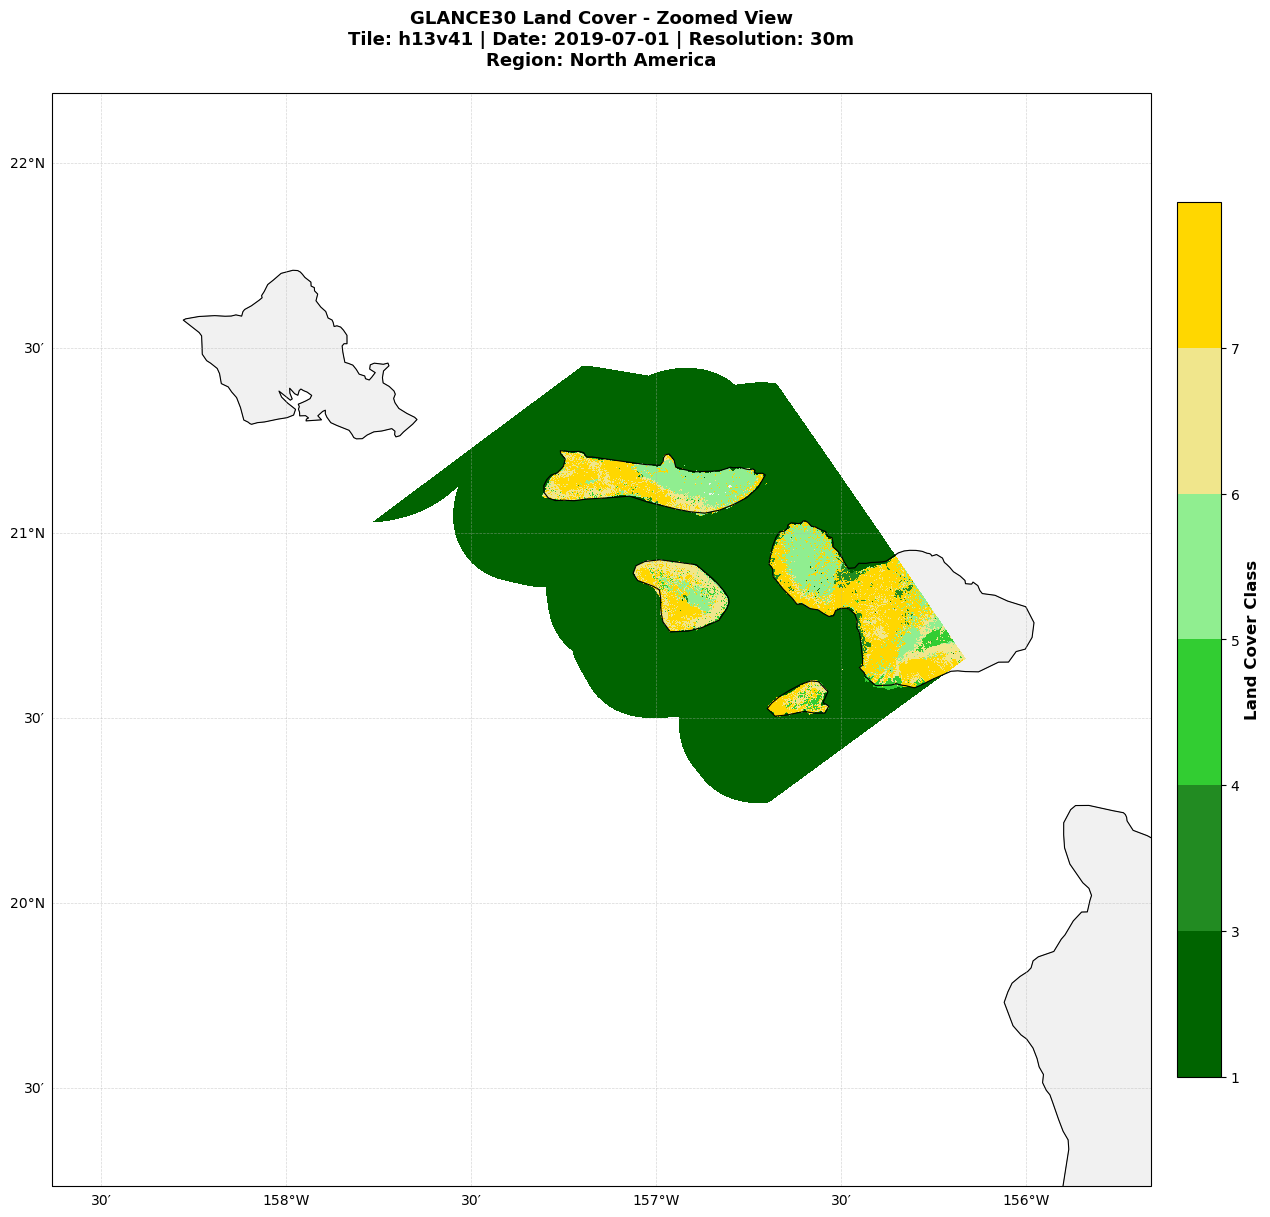

In [7]:
# Create figure with zoomed view
fig = plt.figure(figsize=(14, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add detailed map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--', alpha=0.7, zorder=2)
ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5, zorder=2)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.RIVERS, linewidth=0.3, zorder=1)

# Add gridlines
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, 
                  alpha=0.5, linewidth=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Plot the land cover data
im = ax.pcolormesh(
    ds['lon0'], 
    ds['lat0'], 
    land_cover,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    shading='auto',
    zorder=1
)

# Set tight extent around the data
margin = 0.5  # degrees
ax.set_extent([lon_min - margin, lon_max + margin, 
               lat_min - margin, lat_max + margin], 
              crs=ccrs.PlateCarree())

# Add colorbar with labels
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cbar.set_label('Land Cover Class', fontsize=12, fontweight='bold')
cbar.set_ticks(actual_values)

# Title with metadata
title_text = (
    'GLANCE30 Land Cover - Zoomed View\n'
    f'Tile: h13v41 | Date: 2019-07-01 | Resolution: 30m\n'
    f'Region: North America'
)
plt.title(title_text, fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('glance30_zoomed_view.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Statistical Summary

Analyze the land cover distribution in this tile.

In [8]:
# Calculate land cover statistics
valid_data = land_cover.values[~np.isnan(land_cover.values)]
unique, counts = np.unique(valid_data, return_counts=True)

# Calculate percentages
total_pixels = len(valid_data)
percentages = (counts / total_pixels) * 100

# Create summary dataframe-like display
print("\n" + "="*60)
print("LAND COVER STATISTICS")
print("="*60)
print(f"{'Class':<10} {'Pixels':<15} {'Percentage':<15} {'Area (km²)'}")
print("-"*60)

# Pixel area: 30m x 30m = 900 m² = 0.0009 km²
pixel_area_km2 = 0.0009

for val, count, pct in zip(unique, counts, percentages):
    area_km2 = count * pixel_area_km2
    print(f"{int(val):<10} {count:<15,} {pct:>6.2f}%       {area_km2:>10,.2f}")

print("-"*60)
print(f"{'TOTAL':<10} {total_pixels:<15,} {'100.00%':<15} {total_pixels * pixel_area_km2:>10,.2f}")
print("="*60)


LAND COVER STATISTICS
Class      Pixels          Percentage      Area (km²)
------------------------------------------------------------
1          10,110,341       79.07%         9,099.31
3          73,954            0.58%            66.56
4          122,498           0.96%           110.25
5          708,433           5.54%           637.59
6          571,563           4.47%           514.41
7          1,199,710         9.38%         1,079.74
------------------------------------------------------------
TOTAL      12,786,499      100.00%          11,507.85


## 6. Create Bar Chart of Land Cover Distribution

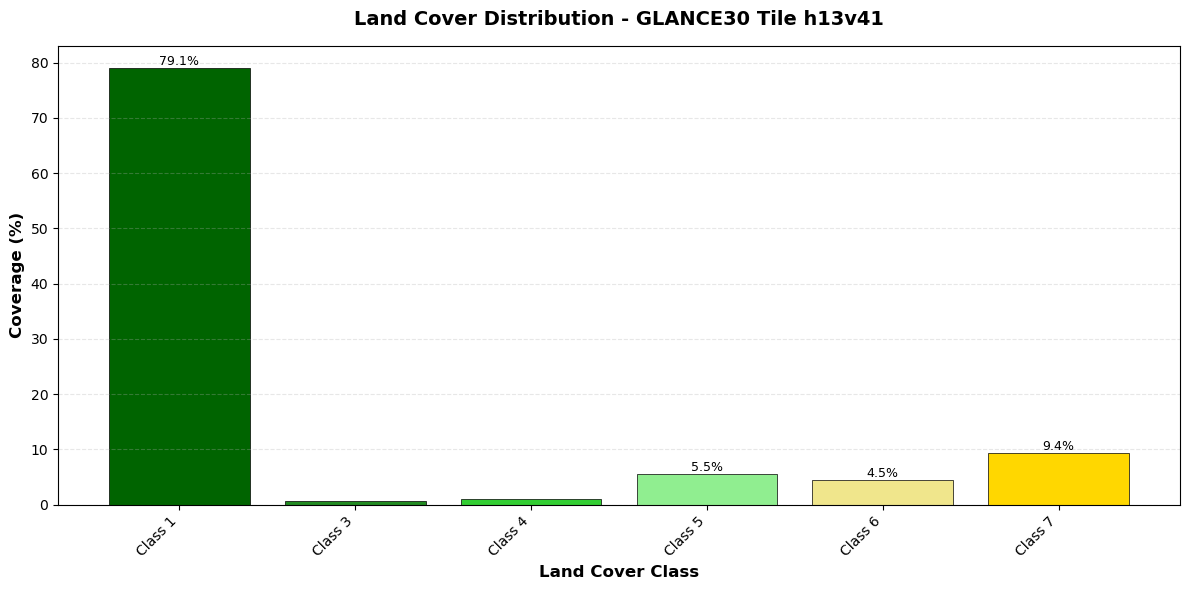

In [9]:
# Create bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Create bars with colors matching the land cover classes
bar_colors = [lc_colors.get(int(v), '#808080') for v in unique]
bars = ax.bar(range(len(unique)), percentages, color=bar_colors, 
              edgecolor='black', linewidth=0.5)

# Customize the plot
ax.set_xlabel('Land Cover Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Coverage (%)', fontsize=12, fontweight='bold')
ax.set_title('Land Cover Distribution - GLANCE30 Tile h13v41', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(len(unique)))
ax.set_xticklabels([f'Class {int(v)}' for v in unique], rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add percentage labels on top of bars
for i, (bar, pct) in enumerate(zip(bars, percentages)):
    if pct > 1:  # Only label bars with >1%
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('glance30_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Additional Analysis - Custom Region Subset

Extract and visualize a specific sub-region of interest.

In [10]:
# Select a subset of the data (center region)
center_i = land_cover.shape[0] // 2
center_j = land_cover.shape[1] // 2
window_size = 1000  # pixels

# Extract subset
i_start = max(0, center_i - window_size // 2)
i_end = min(land_cover.shape[0], center_i + window_size // 2)
j_start = max(0, center_j - window_size // 2)
j_end = min(land_cover.shape[1], center_j + window_size // 2)

subset_lc = land_cover[i_start:i_end, j_start:j_end]
subset_lon = ds['lon0'][i_start:i_end, j_start:j_end]
subset_lat = ds['lat0'][i_start:i_end, j_start:j_end]

print(f"Subset shape: {subset_lc.shape}")
print(f"Subset extent: Lon [{float(subset_lon.min()):.2f}, {float(subset_lon.max()):.2f}], "
      f"Lat [{float(subset_lat.min()):.2f}, {float(subset_lat.max()):.2f}]")

Subset shape: (1000, 1000)
Subset extent: Lon [-157.34, -156.95], Lat [20.52, 20.91]


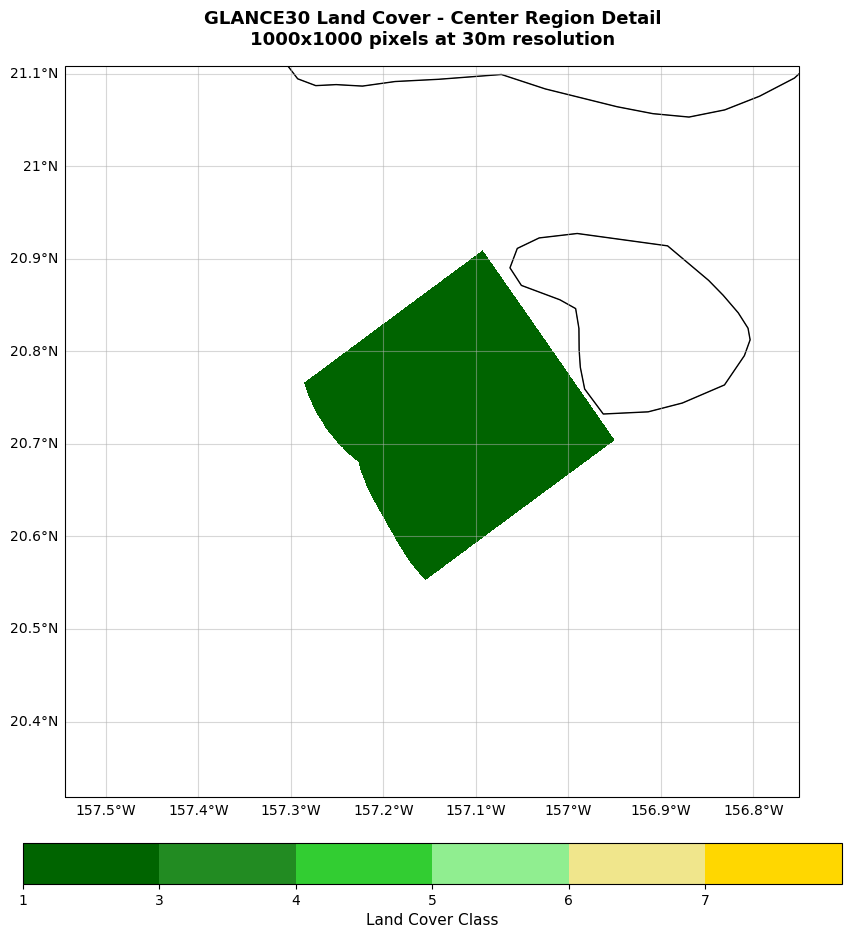

In [11]:
# Visualize the subset
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.7, linestyle='--')
ax.add_feature(cfeature.STATES, linewidth=0.4, alpha=0.6)

# Plot subset
im = ax.pcolormesh(
    subset_lon, 
    subset_lat, 
    subset_lc,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    shading='auto'
)

# Set extent
subset_margin = 0.2
ax.set_extent(
    [float(subset_lon.min()) - subset_margin, float(subset_lon.max()) + subset_margin,
     float(subset_lat.min()) - subset_margin, float(subset_lat.max()) + subset_margin],
    crs=ccrs.PlateCarree()
)

# Gridlines
gl = ax.gridlines(draw_labels=True, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Colorbar
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cbar.set_label('Land Cover Class', fontsize=11)
cbar.set_ticks(actual_values)

plt.title(f'GLANCE30 Land Cover - Center Region Detail\n'
          f'{window_size}x{window_size} pixels at 30m resolution',
          fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('glance30_subset_view.png', dpi=200, bbox_inches='tight')
plt.show()

## 8. Close the Dataset

In [12]:
# Close the dataset to free memory
ds.close()
print("Dataset closed successfully.")

Dataset closed successfully.


---

## Summary

This notebook demonstrates:
1. Loading GLANCE30 land cover data with xarray
2. Visualizing on a global map context
3. Creating zoomed views with detailed cartographic features
4. Statistical analysis of land cover distribution
5. Custom subset visualization for detailed inspection

### Next Steps:
- Adjust the land cover color scheme based on GLANCE30's classification
- Compare multiple tiles or time periods
- Perform change detection analysis
- Export results to GeoTIFF or other formats